In [4]:
%pprint
%load_ext supriya.ext.ipython

import warnings

warnings.filterwarnings(action="default", module="supriya")

from supriya.scsynth import kill

kill()

Pretty printing has been turned OFF


In [ ]:
# soundcheck

March 18th, 2025

# Supriya: a Python API for SuperCollider

Joséphine Wolf Oberholtzer (she / her)

## Introduction

- who am i
- what is supriya
- what isn't it
- what is this presentation
- what isn't this presentation
- what's in a name
- presentation overview

## Servers

### Import supriya

In [2]:
import supriya

In [ ]:
dir(supriya)

### Import `Server`

In [16]:
from supriya import Server

In [17]:
server = Server()

In [ ]:
dir(server)

### Server options

In [ ]:
server

In [ ]:
# TODO: Make Options a dataclass
server.options

### Boot the server

In [18]:
server.boot()

<Server ONLINE [/Applications/SuperCollider.app/Contents/Resources/scsynth -R 0 -l 1 -u 57110]>

### Inspect the server

In [ ]:
server.status

In [ ]:
print(tree := server.query_tree())

In [ ]:
# this is actually a query tree object, not just a string
# ... which is helpful in more complex unit testing situations
# ... because the tree can be annotated with information beyond what scsynth provides
tree

### Reset the server

In [ ]:
# without quitting...
# - delete all nodes and synthdefs
# - and clear all allocators
server.reset()

In [ ]:
print(server.query_tree())

### Quit the server

In [ ]:
server.quit()

### Boot with options

In [ ]:
server.boot(maximum_logins=2)

### Multiple users

In [ ]:
# We can create a handle to a second server proxy,
# pointed back at the same IP address and port as the first
other_server = Server()
other_server

In [ ]:
server  # note the port is the same as `other_server`

In [ ]:
other_server.connect()  # connect to the original server via .connect()

In [ ]:
print(f"{server.client_id=}")
print(f"{other_server.client_id=}")

In [ ]:
other_server.disconnect()  # disconnect from the original server

In [ ]:
server  # the original server remains online

n.b. it's not clear to me how to release a client ID once consumed

### Lifecycle events

In [ ]:
def on_event(event):
    print(event)

for event_type in supriya.ServerLifecycleEvent:
    server.on(event_type, on_event)
    other_server.on(event_type, on_event)

In [ ]:
server.reboot()

In [ ]:
# this will panic
other_server.boot()

In [ ]:
server.quit()

## Entities

### Groups

In [ ]:
server = Server().boot()

In [ ]:
# add a group
group = server.add_group()
group

In [ ]:
print(dir(group))

In [ ]:
print(server.query_tree())

In [ ]:
# add a group to the group
child_group = group.add_group()
print(server.query_tree())

In [ ]:
# move the child group into the default group
child_group.move(target_node=server.default_group, add_action="ADD_TO_TAIL")
print(server.query_tree())

In [ ]:
# free the original parent group
group.free()
print(server.query_tree())

### Synths

In [ ]:
# add a synth (this will fail, silently)
synth = child_group.add_synth(synthdef=supriya.default)

In [ ]:
# we have a proxy to a synth
synth

In [ ]:
# but nothing on the server, because the request failed
print(server.query_tree())

In [ ]:
# using on_completion keyword argument
server.add_synthdefs(
    supriya.default,
    on_completion=lambda server: child_group.add_synth(synthdef=supriya.default),
) 
server.sync()
print(server.query_tree())

In [ ]:
# using completion context manager
with server.at():
    with server.add_synthdefs(supriya.default):
        synth = child_group.add_synth(synthdef=supriya.default, frequency=666)
server.sync()
print(server.query_tree())

In [ ]:
synth.set(frequency=555)

In [ ]:
synth.free()

In [ ]:
# free the remaining synth in the child group by cascading a control setting
child_group.set(gate=0)

### Buses

- calculation rates
- allocate and free
- buses vs bus groups
- shared memory

In [ ]:
# add a control bus
control_bus = server.add_bus()
control_bus

In [ ]:
# add an audio bus
audio_bus = server.add_bus("audio")
audio_bus

In [ ]:
# add a bus group
control_bus_group = server.add_bus_group(count=4)
control_bus_group

In [ ]:
# a bus group aggregates together bus objects
for bus in control_bus_group:
    print(bus)

In [ ]:
# buses and bus groups all can be expressed as map symbols
for bus_like in (control_bus, audio_bus, control_bus_group):
    print(bus_like.map_symbol())

In [ ]:
# we can map buses to synth controls
synth.map(amplitude=control_bus, frequency=audio_bus)
print(server.query_tree())

In [ ]:
# we can release the bus IDs back to the allocator pools
for bus_like in (control_bus, audio_bus, control_bus_group):
    bus_like.free()

### Buffers

- allocate and free
- read sound files
- generating
- plotting

In [13]:
# i can't remember this one, so let's ask for help
help(server.add_buffer)

Help on method add_buffer in module supriya.contexts.core:

add_buffer(
    *,
    channel_count: Optional[int] = None,
    channel_indices: Optional[List[int]] = None,
    file_path: Optional[os.PathLike] = None,
    frame_count: Optional[int] = None,
    starting_frame: Optional[int] = None,
    on_completion: Optional[Callable[[ForwardRef('Context')], NoneType]] = None
) -> supriya.contexts.entities.Buffer method of supriya.contexts.realtime.Server instance
    Add a new buffer to the context.

    Emit ``/b_alloc``, ``/b_allocRead`` or ``/b_allocReadChannel`` requests
    depending on parameters.

    :param channel_count: The channel count of the new buffer. Cannot be used when
        reading from file paths.
    :param channel_indices: The channels to read from a file when reading from a
        file.
    :param file_path: The (optional) file to read from.
    :param frame_count: The frame count of the new buffer.
    :param starting_frame: The frame to start reading from when r

In [19]:
# add a mono buffer with 64 frames
buffer = server.add_buffer(channel_count=1, frame_count=64)

In [20]:
# query the buffer
buffer.query()

BufferInfo(items=[BufferInfo.Item(buffer_id=0, frame_count=64, channel_count=1, sample_rate=44100.0)])

In [ ]:
# i can't remember this one either
help(buffer.generate)

In [25]:
# generate a chebyshev polynomial in wavetable format
buffer.generate("cheby", amplitudes=[0.1, 0.2, 0.05], as_wavetable=True)

In [26]:
# get values at indices in the buffer
buffer.get(0, 2, 4, 8)

{0: 0.266357421875,
 2: 0.25126951932907104,
 4: 0.2346191555261612,
 8: 0.19780273735523224}

In [27]:
# get a range of values
buffer.get_range(index=0, count=16)

(0.266357421875,
 -0.016357421875,
 0.25126951932907104,
 -0.01762695237994194,
 0.2346191555261612,
 -0.01860351487994194,
 0.21669922769069672,
 -0.01928711123764515,
 0.19780273735523224,
 -0.01967773400247097,
 0.17822265625,
 -0.019775390625,
 0.15825195610523224,
 -0.01958007737994194,
 0.13818359375,
 -0.01909179799258709)

In [28]:
# import rendering functions
from supriya import play, plot

PosixPath('/Users/josephine/Library/Caches/supriya/2025-02-16T15-38-27-128279.png')

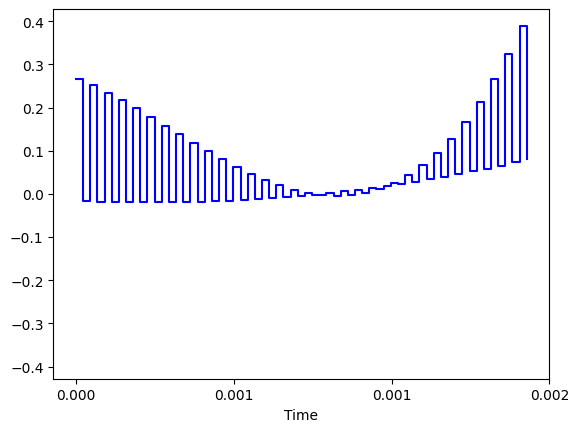

In [30]:
# plot the buffer
await plot(buffer)

PosixPath('/Users/josephine/Library/Caches/supriya/2025-02-16T15-38-41-979872.png')

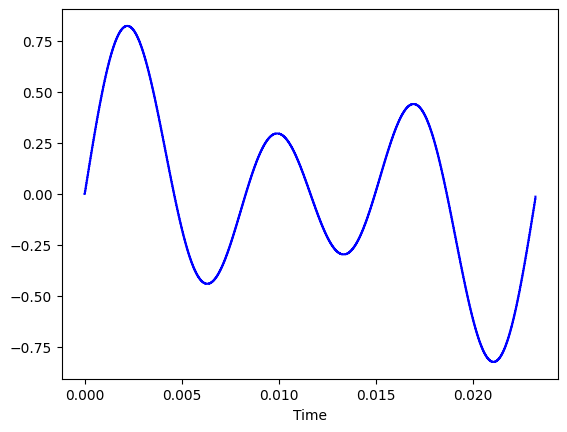

In [32]:
# create a second buffer and generate differently
other_buffer = server.add_buffer(frame_count=1024)
other_buffer.generate("sine1", amplitudes=[0.1, 0.3, 0.5])
await plot(other_buffer)

PosixPath('/Users/josephine/Library/Caches/supriya/2025-02-16T15-38-54-451698.png')

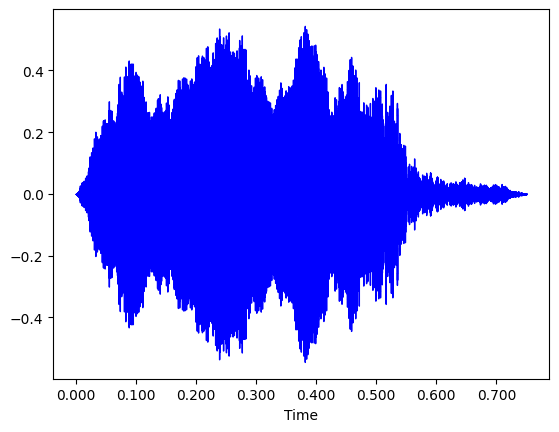

In [34]:
# read a file into a buffer
file_path = supriya.assets_path / "audio/birds/birds-01.wav"
yet_another_buffer = server.add_buffer(file_path=file_path)
await plot(yet_another_buffer)

In [35]:
# normally play() isn't async
# but for fussy reasons related to jupyter itself being async,
# we have to await here
await play(yet_another_buffer)

(PosixPath('/Users/josephine/Library/Caches/supriya/audio-0c7c3ecda2db627616c356d1832925fd61bb4ab55870f54b5e3802f59a33608e.mp3'),
 0)

In [37]:
# allocate a group of buffers, e.g.
buffer_group = server.add_buffer_group(count=4, frame_count=512, channel_count=1)
print(buffer_group)
for buffer_ in buffer_group:
    print(buffer_)

BufferGroup(context=<Server ONLINE [/Applications/SuperCollider.app/Contents/Resources/scsynth -R 0 -l 1 -u 57110]>, id_=9, count=4)
Buffer(context=<Server ONLINE [/Applications/SuperCollider.app/Contents/Resources/scsynth -R 0 -l 1 -u 57110]>, id_=9, completion=None)
Buffer(context=<Server ONLINE [/Applications/SuperCollider.app/Contents/Resources/scsynth -R 0 -l 1 -u 57110]>, id_=10, completion=None)
Buffer(context=<Server ONLINE [/Applications/SuperCollider.app/Contents/Resources/scsynth -R 0 -l 1 -u 57110]>, id_=11, completion=None)
Buffer(context=<Server ONLINE [/Applications/SuperCollider.app/Contents/Resources/scsynth -R 0 -l 1 -u 57110]>, id_=12, completion=None)


In [38]:
# free all the buffers
buffer.free()
other_buffer.free()
yet_another_buffer.free()
buffer_group.free()

### Enums

In [ ]:
# calculation rates are expressed via an enum
from supriya import CalculationRate

for rate in sorted(CalculationRate):
    print(repr(rate), rate)

## Messages

In [ ]:
server.reset()

In [ ]:
server.osc_protocol

In [ ]:
with server.osc_protocol.capture() as transcript:
    with server.at():
        with server.add_synthdefs(supriya.default):
            group = server.add_group()
            synth = group.add_synth(synthdef=supriya.default, frequency=666)

In [ ]:
for x in transcript: print(x)

### OSC messages & bundles

### Sending messages

In [ ]:
server.send([])

### OSC protocols

In [ ]:
server.osc_protocol

### Capturing IO

In [ ]:
with server.osc_protocol.capture() as transcript:
    with server.at():
        group = server.add_group()
        with server.add_synthdefs(supriya.default):
            synth = group.add_synth(synthdef=supriya.default, frequency=666)
    server.sync()

In [ ]:
for entry in transcript:
    print(entry)

### Moments & completions

### Requests & responses

In [39]:
import supriya.contexts.requests

dir(supriya.contexts.requests)

['ABC',
 'AddAction',
 'AddActionLike',
 'AllocateBuffer',
 'AllocateReadBuffer',
 'AllocateReadBufferChannel',
 'AutoReassignSynthID',
 'ClearSchedule',
 'CloseBuffer',
 'CopyBuffer',
 'Dict',
 'DoNothing',
 'DumpOsc',
 'DumpTree',
 'FillBuffer',
 'FillControlBusRange',
 'FillNode',
 'FreeAllSynthDefs',
 'FreeBuffer',
 'FreeGroupChildren',
 'FreeGroupDeep',
 'FreeNode',
 'FreeSynthDef',
 'Future',
 'GenerateBuffer',
 'GetBuffer',
 'GetBufferRange',
 'GetControlBus',
 'GetControlBusRange',
 'GetSynthControl',
 'GetSynthControlRange',
 'HeaderFormat',
 'HeaderFormatLike',
 'List',
 'Literal',
 'LoadSynthDefDirectory',
 'LoadSynthDefs',
 'MapAudioBusRangeToNode',
 'MapAudioBusToNode',
 'MapControlBusRangeToNode',
 'MapControlBusToNode',
 'MoveNodeAfter',
 'MoveNodeBefore',
 'MoveNodeToGroupHead',
 'MoveNodeToGroupTail',
 'NewGroup',
 'NewParallelGroup',
 'NewSynth',
 'NormalizeBuffer',
 'Optional',
 'OrderNodes',
 'OscBundle',
 'OscMessage',
 'PathLike',
 'QueryBuffer',
 'QueryNode',
 'Q

## Synthdefs

### Building SynthDefs (1)

In [ ]:
r"""
SynthDef(\simple, { arg out=0, freq=440;
	Out.ar(out, SinOsc.ar(freq));
});
"""

In [ ]:
# A simple SynthDef using the builder pattern
from supriya.ugens import SynthDefBuilder
from supriya.ugens import Out, SinOsc

with SynthDefBuilder(freq=440, out=0) as builder:
    source = SinOsc.ar(frequency=builder["freq"])
    Out.ar(bus=builder["out"], source=[source, source])

simple_synthdef = builder.build(name="simple")
simple_synthdef

### Building SynthDefs (2)

In [ ]:
r"""
*makeDefaultSynthDef {
    SynthDef(\default, { arg out=0, freq=440, amp=0.1, pan=0, gate=1;
        var z;
        z = LPF.ar(
            Mix.new(VarSaw.ar(freq + [0, Rand(-0.4,0.0), Rand(0.0,0.4)], 0, 0.3, 0.3)),
            XLine.kr(Rand(4000,5000), Rand(2500,3200), 1)
        ) * Linen.kr(gate, 0.01, 0.7, 0.3, 2);
        OffsetOut.ar(out, Pan2.ar(z, pan, amp));
    }, [\ir]).add;
}
"""

In [ ]:
# More imports
from supriya.enums import DoneAction, ParameterRate
from supriya.ugens import (
    LPF,
    Linen,
    Mix,
    OffsetOut,
    Pan2,
    Parameter,
    Rand,
    SynthDefBuilder,
    VarSaw,
    XLine,
)

In [ ]:
# Define a builder
builder = SynthDefBuilder(
    out=Parameter(rate=ParameterRate.SCALAR, value=0),
    amplitude=0.1,
    frequency=440,
    gate=1,
    pan=0.5,
)

In [ ]:
# Use the builder as a context manager
with builder:
    linen = Linen.kr(
        attack_time=0.01,
        done_action=DoneAction.FREE_SYNTH,
        gate=builder["gate"],
        release_time=0.3,
        sustain_level=0.7,
    )

In [ ]:
# Use the builder again
with builder:
    low_pass = LPF.ar(
        source=Mix.new(
            VarSaw.ar(
                frequency=builder["frequency"]
                + (
                    0,
                    Rand.ir(minimum=-0.4, maximum=0.0),
                    Rand.ir(minimum=0.0, maximum=0.4),
                ),
                width=0.3,
            )
        )
        * 0.3,
        frequency=XLine.kr(
            start=Rand.ir(minimum=4000, maximum=5000),
            stop=Rand.ir(minimum=2500, maximum=3200),
        ),
    )

In [ ]:
# And again and again
with builder:
    panner = Pan2.ar(
        source=low_pass * linen * builder["amplitude"], position=builder["pan"]
    )

with builder:
    OffsetOut.ar(bus=builder["out"], source=panner)

In [ ]:
default = builder.build(name="default")
default

### The `synthdef` decorator

In [ ]:
# N.B. I'm not fond of this one because of
# a) how magical it is (not very, but just enough) but mainly because
# b) it makes type-checking difficult
from supriya.ugens import synthdef

In [ ]:
@synthdef("ir")
def default_decorated(out=0, amplitude=0.1, frequency=440, gate=1, pan=0.5):
    linen = Linen.kr(
        attack_time=0.01,
        done_action=DoneAction.FREE_SYNTH,
        gate=gate,
        release_time=0.3,
        sustain_level=0.7,
    )
    low_pass = LPF.ar(
        source=Mix.new(
            VarSaw.ar(
                frequency=frequency
                + (
                    0,
                    Rand.ir(minimum=-0.4, maximum=0.0),
                    Rand.ir(minimum=0.0, maximum=0.4),
                ),
                width=0.3,
            )
        )
        * 0.3,
        frequency=XLine.kr(
            start=Rand.ir(minimum=4000, maximum=5000),
            stop=Rand.ir(minimum=2500, maximum=3200),
        ),
    )
    panner = Pan2.ar(
        source=low_pass * linen * amplitude, position=pan
    )
    _ = OffsetOut.ar(bus=out, source=panner)

In [ ]:
default_decorated

In [ ]:
from supriya.ugens import Out, SinOsc

@synthdef()
def foo(out=0):
    print(repr(out))
    _ = Out.ar(source=SinOsc.kr())

foo

### Graphing SynthDefs

In [ ]:
print(default)

In [ ]:
from supriya import graph

_ = graph(default)

### SynthDef internals

In [ ]:
dir(default)

In [ ]:
default.name

In [ ]:
default.anonymous_name

In [ ]:
default.effective_name

In [ ]:
default.parameters

In [ ]:
default.ugens

In [ ]:
default.has_gate

### UGen methods

In [ ]:
dir(SinOsc)

### SynthDef (de)compilation

In [ ]:
# SynthDefs compile to byte strings
compiled = default.compile()
compiled

In [ ]:
# valid byte strings can be decompiled back into SynthDefs
from supriya.ugens import decompile_synthdef

decompiled = decompile_synthdef(compiled)
decompiled

In [ ]:
# sanity-check: the decompiled SynthDef is not the same in memory
default is decompiled

### Compiling via sclang

In [ ]:
# Supriya provides utilities for compiling via sclang.
# This is intended for validating its own logic vs sclang (as a reference spec).
from supriya.ugens import SuperColliderSynthDef

sc_synthdef = SuperColliderSynthDef(
    "foo", "Out.ar(0, SinOsc.ar(freq: 420) * SinOsc.ar(freq: 440))"
)
sc_compiled_synthdef = sc_synthdef.compile()  # return bytes
sc_compiled_synthdef

In [ ]:
# The sclang-derived SynthDef byte string can be decompiled back into a SynthDef.
print(decompile_synthdef(sc_compiled_synthdef))

### UGen metaprogramming

In [ ]:
from supriya.ugens import UGen, param, ugen

# A dupe of SinOsc
@ugen(ar=True, kr=True, is_pure=True)
class AnotherSinOsc(UGen):
    frequency = param(440.0)
    phase = param(0.0)

In [ ]:
AnotherSinOsc.ar()

In [ ]:
AnotherSinOsc.kr()

In [ ]:
# This won't work because ir=True wasn't set
AnotherSinOsc.ir()

In [ ]:
# A dupe of Out
@ugen(ar=True, kr=True, is_output=True, channel_count=0, fixed_channel_count=True)
class AnotherOut(UGen):
    bus = param(0)
    source = param(unexpanded=True)

AnotherOut.ar(source=AnotherSinOsc.ar())

In [ ]:
from supriya.ugens.pv import PV_ChainUGen

# A dupe of PV_BinShift
@ugen(kr=True, is_width_first=True)
class AnotherPV_BinShift(PV_ChainUGen):
    pv_chain = param()
    stretch = param(1.0)
    shift = param(0.0)
    interpolate = param(0)

# This won't work because of missing pv_chain argument
AnotherPV_BinShift.kr()

In [ ]:
"""
def ugen(
    *,
    ar: bool = False,
    kr: bool = False,
    ir: bool = False,
    dr: bool = False,
    new: bool = False,
    has_done_flag: bool = False,
    is_input: bool = False,
    is_multichannel: bool = False,
    is_output: bool = False,
    is_pure: bool = False,
    is_width_first: bool = False,
    channel_count: int = 1,
    fixed_channel_count: bool = False,
    signal_range: Optional[int] = None,
) -> Callable[[Type["UGen"]], Type["UGen"]]:
    ...
"""

## Non-Realtime

In [17]:
from supriya import Score, default, play

score = Score()
score  # TODO: repr doesn't make a lotta sense

<Score ONLINE [/Applications/SuperCollider.app/Contents/Resources/scsynth -R 0 -l 1 -u 57110]>

In [16]:
# inspect the score's namespace
# note: no queries, only mutations
dir(score)

['__abstractmethods__', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__render__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_add_request_with_completion', '_add_requests', '_allocate_id', '_apply_completions', '_audio_bus_allocator', '_boot_status', '_buffer_allocator', '_client_id', '_control_bus_allocator', '_free_id', '_get_allocator', '_get_moment', '_get_next_sync_id', '_get_request_context', '_latency', '_lock', '_name', '_node_id_allocator', '_options', '_pop_completion', '_pop_moment', '_push_completion', '_push_moment', '_requests', '_resolve_node', '_setup_allocators', '_sync_id', '_sync_id_maximum', '_sync_id_minim

In [ ]:
# add a synthdef at timestamp 0
with score.at(0):
    score.add_synthdefs(default)

# strum a series of 
synths = []
for i in range(12):
    with score.at(i / 4):
        synth = score.add_synth(synthdef=default, frequency=111 * (i + 1))

with score.at(3):
    for synth in synths:
        synth.free()

with score.at(4):
    score.do_nothing()

In [28]:
# play the score (and capture into the notebook)
_ = await play(score)

In [27]:
# render the score, returning the path and exit code
await score.render()

(PosixPath('/Users/josephine/Library/Caches/supriya/score-b5e6166319aa99a4a61cb3ce6e5e79fda03de211129e3ea3043e3dfda894feb8.aiff'), 0)

In [15]:
# no queries, only mutations
with score.at(0):
    score.query_tree()

AttributeError: 'Score' object has no attribute 'query_tree'

In [29]:
# TODO: let's fix OSC reprs once and for all
for bundle in score.iterate_osc_bundles():
    print(repr(bundle))

OscBundle(
    contents=(
        OscMessage('/d_recv', b'SCgf\x00\x00\x00\x02\x00\x01\x07default\x00\x00\x00\x0c\x00\x00\x00\x00>\x99\x99\x9a<#\xd7\n?333@\x00\x00\x00\xbe\xcc\xcc\xcd>\xcc\xcc\xcdEz\x00\x00E\x9c@\x00E\x1c@\x00EH\x00\x00?\x80\x00\x00\x00\x00\x00\x05=\xcc\xcc\xcdC\xdc\x00\x00?\x80\x00\x00?\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x05\tamplitude\x00\x00\x00\x00\tfrequency\x00\x00\x00\x01\x04gate\x00\x00\x00\x02\x03pan\x00\x00\x00\x03\x03out\x00\x00\x00\x04\x00\x00\x00\x14\x07Control\x01\x00\x00\x00\x00\x00\x00\x00\x04\x00\x00\x01\x01\x01\x01\x06VarSaw\x02\x00\x00\x00\x03\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\xff\xff\xff\xff\x00\x00\x00\x00\xff\xff\xff\xff\x00\x00\x00\x01\x02\x05Linen\x01\x00\x00\x00\x05\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x02\xff\xff\xff\xff\x00\x00\x00\x02\xff\xff\xff\xff\x00\x00\x00\x03\xff\xff\xff\xff\x00\x00\x00\x01\xff\xff\xff\xff\x00\x00\x00\x04\x01\x07Control\x00\x00\x00\x00\x00\x00\x00\x00\x01\x00\x04\x00\x04Rand\x

In [13]:
for bundle in score.iterate_request_bundles():
    print(bundle)

RequestBundle(contents=[ReceiveSynthDefs(synthdefs=(<SynthDef: default>,), on_completion=None), NewSynth(synthdef=<SynthDef: default>, synth_id=1000, add_action=AddAction.ADD_TO_HEAD, target_node_id=0, controls={'frequency': 111.0})], timestamp=0.0)
RequestBundle(contents=[NewSynth(synthdef=<SynthDef: default>, synth_id=1001, add_action=AddAction.ADD_TO_HEAD, target_node_id=0, controls={'frequency': 222.0})], timestamp=0.25)
RequestBundle(contents=[NewSynth(synthdef=<SynthDef: default>, synth_id=1002, add_action=AddAction.ADD_TO_HEAD, target_node_id=0, controls={'frequency': 333.0})], timestamp=0.5)
RequestBundle(contents=[NewSynth(synthdef=<SynthDef: default>, synth_id=1003, add_action=AddAction.ADD_TO_HEAD, target_node_id=0, controls={'frequency': 444.0})], timestamp=0.75)
RequestBundle(contents=[NewSynth(synthdef=<SynthDef: default>, synth_id=1004, add_action=AddAction.ADD_TO_HEAD, target_node_id=0, controls={'frequency': 555.0})], timestamp=1.0)
RequestBundle(contents=[NewSynth(syn

## Clocks & Patterns

## Concurrency

- server
- async server
- threaded concurrency
- event loop / coroutine concurrency

## Mixers

## Cleanliness

- docs
- typing
- testing
- ci/cd